## Nearest-neighbour resampling

**Nearest-neighbour** resampling assigns each output pixel the value of the closest source grid cell, with no interpolation. The result preserves the exact data values and shows crisp, block-like cell boundaries — ideal for visualising the native structure of the source grid.

Use `NearestNeighbour` when:
- you want to inspect the **raw grid cell structure** of your data, or
- your field contains **discrete categories** (e.g. land-use, cloud type) where averaging between cells would be meaningless.

For smooth, interpolated rendering, see the [Bilinear notebook](resampling-bilinear.ipynb).

### Example: 2 m temperature over Europe

We will use a sample GRIB file containing 2 m temperature on a regular lat/lon grid.

In [2]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "test.grib").to_fieldlist()
data.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2020-05-13 12:00:00,2020-05-13 12:00:00,0 days,0,surface,0,regular_ll
1,msl,2020-05-13 12:00:00,2020-05-13 12:00:00,0 days,0,surface,0,regular_ll


### Default pixel count

Calling `NearestNeighbour()` with no arguments uses **1000 × 1000 pixels**. Each pixel is coloured with the value of whichever source grid cell its centre falls closest to, so you can clearly see the boundaries between cells.

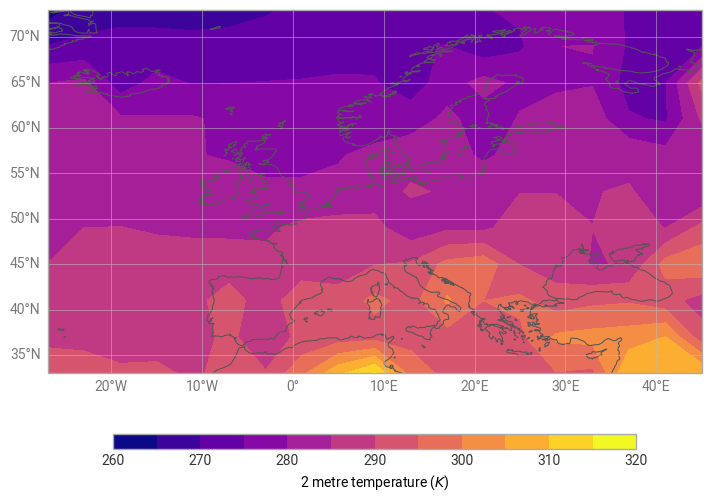

In [6]:
from earthkit.plots.resample import NearestNeighbour

chart = ekp.Map()

chart.contourf(data, resample=NearestNeighbour())

chart.coastlines()
chart.gridlines()
chart.legend()

chart.show()

### Comparing Bilinear and NearestNeighbour

The difference between the two methods is most visible at low resolution. Here we use a coarse pixel count to make the individual cells clearly visible.

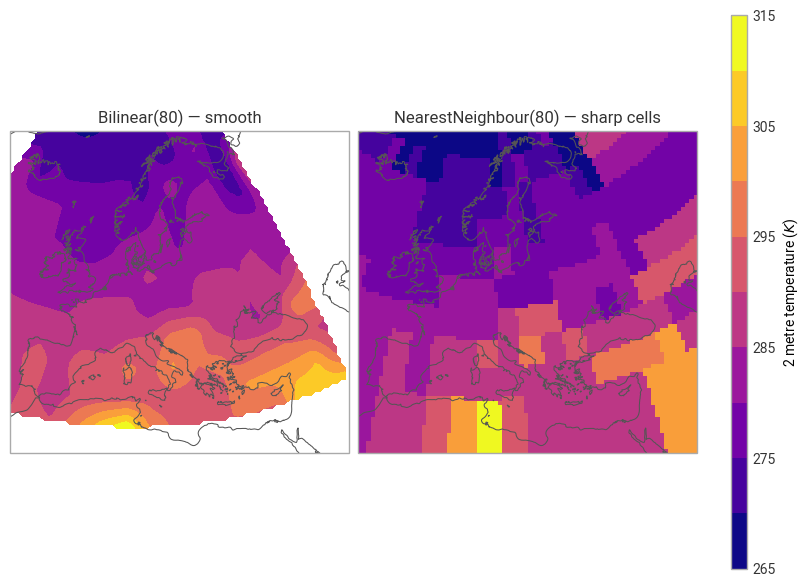

In [4]:
from earthkit.plots.resample import Bilinear

figure = ekp.Figure(rows=1, columns=2, domain="Europe")

ax = figure.add_map()
ax.contourf(data, resample=Bilinear(80))
ax.title("Bilinear(80) — smooth")

ax = figure.add_map()
ax.contourf(data, resample=NearestNeighbour(80))
ax.title("NearestNeighbour(80) — sharp cells")

figure.coastlines()
figure.legend(location="right")

figure.show()

### Controlling pixel count and resolution

Like `Bilinear`, you can set a fixed pixel count or use `NearestNeighbour.at_resolution(dx)` to specify the pixel spacing in degrees. A finer resolution retains the cell-boundary sharpness while showing more cells.

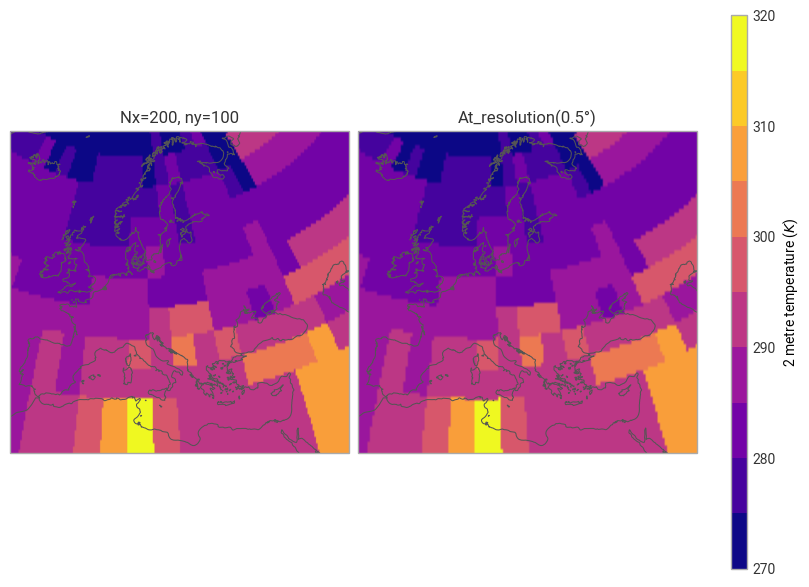

In [5]:
figure = ekp.Figure(rows=1, columns=2, domain="Europe")

# Fixed pixel count
ax = figure.add_map()
ax.contourf(data, resample=NearestNeighbour(nx=200, ny=100))
ax.title("nx=200, ny=100")

# Resolution-based: one pixel per 0.5 degrees
ax = figure.add_map()
ax.contourf(data, resample=NearestNeighbour.at_resolution(0.5))
ax.title("at_resolution(0.5°)")

figure.coastlines()
figure.legend(location="right")

figure.show()

<div class="alert alert-block alert-info">
<strong>NOTE:</strong> <code>NearestNeighbour</code> is only valid for regular rectilinear source grids. For curvilinear grids it automatically falls back to <code>Bilinear</code>. For HEALPix or reduced Gaussian grids, first regrid with <code>Regrid</code> and then apply <code>NearestNeighbour</code> via a <code>Chain</code>.
</div>